In [44]:
import os
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
try:
    import cmaps
except ImportError:
    import types
    class _CmapsFallback(types.SimpleNamespace):
        WhiteBlueGreenYellowRed = 'Spectral_r'
        NCV_blu_red = 'RdBu_r'
        def __getattr__(self, name):
            return 'Spectral_r'
    cmaps = _CmapsFallback()
    sys.modules.setdefault('cmaps', cmaps)
# 添加wave_tools到路径
BASE_DIR = '/work/mh1498/m301257'
sys.path.insert(0, BASE_DIR)
import matplotlib.gridspec as gridspec
from wave_tools.filters import CCKWFilter
from wave_tools.spectral import calculate_wk_spectrum
from wave_tools.plotting import plot_wk_spectrum
from wave_tools.utils import convert_icon_to_latlon_grid, batch_convert_icon_to_latlon
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from matplotlib.colors import ListedColormap 
myCmap1 = ListedColormap(['#ffffff','#ffffc7','#fff98e','#ffd556','#ff9c1d','#e36400','#a92a00','#710500','#380000','#000000'])
print(f" 工作目录: {BASE_DIR}")

import matplotlib as mpl
import cartopy.feature as cfeature

 工作目录: /work/mh1498/m301257


In [45]:


# ── AGU 全局样式（模块级，只需执行一次）──────────────────────────────────────
mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         8,
    "axes.titlesize":    9,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":    0.6,
    "lines.linewidth":   0.8,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

In [46]:
ds = xr.open_dataset(r'/work/mh1498/m301257/processed_data_lat_30/2d_layers/pr_cntl/pr_2deg_interp.nc')
ds  = ds.sel(time=slice('1980-01-01', '1993-12-31'))
ds

<xarray.Dataset> Size: 273MB
Dimensions:  (time: 5114, lat: 37, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 296B -36.0 -34.0 -32.0 -30.0 ... 30.0 32.0 34.0 36.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    pr       (time, lat, lon) float64 272MB ...

In [47]:
pr_seasonal_mean = ds['pr'].groupby('time.season').mean('time')
pr_seasonal_mean

<xarray.DataArray 'pr' (season: 4, lat: 37, lon: 180)> Size: 213kB
array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [1.25482937e-05, 1.08462929e-05, 8.58662208e-06, ...,
         1.89580502e-05, 1.71841192e-05, 1.44634937e-05],
        [8.23036894e-06, 8.06127717e-06, 6.41458191e-06, ...,
         1.51893107e-05, 1.30962899e-05, 1.14461974e-05],
        ...,
        [9.23067502e-07, 1.25648627e-06, 9.80095253e-07, ...,
         1.30819668e-05, 1.10139346e-06, 1.21911352e-06],
        [3.82079098e-06, 5.93203675e-06, 1.74033881e-06, ...,
         1.37327950e-05, 1.19411699e-05, 4.00840482e-06],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [3.25992450e-05, 3.03018435e-05, 2.91223798e-05, ...,
         4.47554422e-05, 3.98099070e-05, 3.61482505e-05],
        [2.35704607e-05, 2.07549682e-05, 1.75775785e-05, ...,
         3.49664479e-05, 3.11497493e-05, 2.81371801e-05],
...
         2.94688950e-05, 3.76770382e-06, 3.30359205e-06],
        [9.96622973e-06, 1.45687492e-05, 4.82582648e-06, ...,
         1.20009122e-05, 1.96972414e-05, 1.21614689e-05],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [2.14510570e-05, 1.77373126e-05, 1.61668142e-05, ...,
         3.17662769e-05, 2.74187898e-05, 2.25088523e-05],
        [1.40193105e-05, 1.15150513e-05, 8.59633464e-06, ...,
         2.52872863e-05, 2.00464068e-05, 1.50032654e-05],
        ...,
        [3.92171769e-06, 2.22647509e-06, 2.51239251e-06, ...,
         2.85733247e-05, 6.91467495e-06, 5.62421780e-06],
        [9.25765726e-06, 1.20598109e-05, 6.12363052e-06, ...,
         1.65816283e-05, 1.86207756e-05, 9.12963136e-06],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]],
      shape=(4, 37, 180))
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float64 296B -36.0 -34.0 -32.0 -30.0 ... 30.0 32.0 34.0 36.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [48]:
ds_p4k = xr.open_dataset(r'/work/mh1498/m301257/processed_data_lat_30/2d_layers/pr_p4k/pr_2deg_interp.nc')
ds_p4k = ds_p4k.sel(time=slice('1980-01-01', '1993-12-31'))
ds_p4k

<xarray.Dataset> Size: 273MB
Dimensions:  (time: 5114, lat: 37, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 296B -36.0 -34.0 -32.0 -30.0 ... 30.0 32.0 34.0 36.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    pr       (time, lat, lon) float64 272MB ...

In [49]:
pr_seasonal_mean_p4k = ds_p4k['pr'].groupby('time.season').mean('time')
pr_seasonal_mean_p4k

<xarray.DataArray 'pr' (season: 4, lat: 37, lon: 180)> Size: 213kB
array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [1.26007213e-05, 9.91894919e-06, 8.36837524e-06, ...,
         2.03795108e-05, 1.79023688e-05, 1.42266626e-05],
        [9.68501599e-06, 7.27162090e-06, 5.38114530e-06, ...,
         1.69381727e-05, 1.56400753e-05, 1.11047581e-05],
        ...,
        [4.43067918e-07, 1.20718902e-07, 1.44686191e-07, ...,
         3.96349926e-06, 2.93277627e-07, 3.94673999e-07],
        [1.52191946e-06, 1.28810435e-06, 6.28638071e-07, ...,
         5.57934040e-06, 4.25141307e-06, 1.33793505e-06],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [3.98992036e-05, 3.23422266e-05, 2.92715236e-05, ...,
         4.42726568e-05, 4.58856536e-05, 4.69450725e-05],
        [2.54687931e-05, 1.94409225e-05, 1.77692183e-05, ...,
         3.88150529e-05, 3.53210118e-05, 3.20626609e-05],
...
         1.85621800e-05, 2.93616042e-06, 2.66210320e-06],
        [5.84168255e-06, 8.75496229e-06, 3.16027880e-06, ...,
         5.46398083e-06, 1.15369695e-05, 6.02664196e-06],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [2.27119030e-05, 2.05216990e-05, 1.62949065e-05, ...,
         3.19680648e-05, 2.71567578e-05, 2.54590965e-05],
        [1.59609241e-05, 1.20475264e-05, 9.83307298e-06, ...,
         2.62853298e-05, 2.16527377e-05, 1.87034426e-05],
        ...,
        [1.71465401e-06, 8.36660333e-07, 1.00064667e-06, ...,
         1.22216771e-05, 3.32363704e-06, 2.95701673e-06],
        [6.68400530e-06, 8.20046256e-06, 3.34725552e-06, ...,
         8.75921611e-06, 8.76912256e-06, 5.78184747e-06],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]],
      shape=(4, 37, 180))
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float64 296B -36.0 -34.0 -32.0 -30.0 ... 30.0 32.0 34.0 36.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [50]:
data_dict = {
    s: pr_seasonal_mean.sel(season=s).values * 86400
    for s in ["DJF", "MAM", "JJA", "SON"]
}
lats = pr_seasonal_mean.lat.values
lons = pr_seasonal_mean.lon.values

data_dict_p4k = {
    s: pr_seasonal_mean_p4k.sel(season=s).values * 86400
    for s in ["DJF", "MAM", "JJA", "SON"]
}

In [51]:

# ─────────────────────────────────────────────────────────────────────────────

def plot_seasonal_pr(
    data_dict,
    lats,
    lons,
    *,
    extend       = None,              # 色标超出范围的处理；None = 不显示，'max' = 上限箭头，'min' = 下限箭头，'both' = 两者都有
    # 区域控制
    extent       = None,          # [lon_min, lon_max, lat_min, lat_max]；None = 全球
    central_lon  = 0,             # 投影中心经度
    # 刻度控制
    dlon         = 60,            # 经度刻度间距（度）
    dlat         = 30,            # 纬度刻度间距（度）
    # 色标控制
    vmin         = 0,
    vmax         = 30,
    cmap         = "YlGnBu",
    nlevels      = 13,
    cbar_label   = "Precipitation / mm d$^{-1}$",
    # 标注
    title        =  None,
    panel_labels = ("(a)", "(b)", "(c)", "(d)"),
    season_titles = None,         # None → 使用默认
    # 图像尺寸与输出
    figsize      = (7.5, 5.8),
    dpi          = 300,
    output       = None,          # 文件路径；None = 不保存
):
    """
    绘制四季降水量空间分布图（2×2，AGU 风格）。

    Parameters
    ----------
    data_dict : dict
        键为 'DJF','MAM','JJA','SON'，值为 2-D ndarray（lat × lon），
        单位 mm day⁻¹。
    lats, lons : 1-D array-like
        与 data_dict 中数组对应的纬度、经度坐标。
    extent : list | None
        [lon_min, lon_max, lat_min, lat_max]，使用 PlateCarree(0) 坐标。
        None 表示全球范围。
    central_lon : float
        投影中心经度，默认 0。太平洋中心视图用 180，海洋性大陆用 120。
    dlon, dlat : float
        经纬度刻度间距。
    vmin, vmax : float
        色标范围。
    cmap : str
        Matplotlib colormap 名称。
    nlevels : int
        等值面层数。
    cbar_label : str
        colorbar 标签。
    title : str
        图标题。
    panel_labels : tuple[str]
        四个子图的面板标签。
    season_titles : dict | None
        自定义子图标题，键为 'DJF'/'MAM'/'JJA'/'SON'。
    figsize : tuple
        画布尺寸（英寸）。
    dpi : int
        输出分辨率。
    output : str | None
        保存路径（如 'pr_MC.png'）。None 则不保存。

    Returns
    -------
    fig, axes : matplotlib Figure 和 ndarray of GeoAxes
    """
    seasons_order = ["DJF", "MAM", "JJA", "SON"]

    if season_titles is None:
        season_titles = {
            "DJF": "DJF (Dec–Jan–Feb)",
            "MAM": "MAM (Mar–Apr–May)",
            "JJA": "JJA (Jun–Jul–Aug)",
            "SON": "SON (Sep–Oct–Nov)",
        }

    LEVELS   = np.linspace(vmin, vmax, nlevels)
    PROJ     = ccrs.PlateCarree(central_longitude=central_lon)
    DATA_CRS = ccrs.PlateCarree()

    # 根据 extent 决定刻度范围
    if extent is not None:
        lon0, lon1, lat0, lat1 = extent
    else:
        lon0, lon1, lat0, lat1 = -180, 180, -90, 90

    lon_ticks = np.arange(
        np.floor(lon0 / dlon) * dlon,
        np.ceil (lon1 / dlon) * dlon + 1,
        dlon,
    )
    lat_ticks = np.arange(
        np.floor(lat0 / dlat) * dlat,
        np.ceil (lat1 / dlat) * dlat + 1,
        dlat,
    )

    # ── 画布 ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        subplot_kw={"projection": PROJ},
    )
    fig.subplots_adjust(
        left=0.07, right=0.97,
        bottom=0.18, top=0.92,
        wspace=0.12, hspace=0.28,
    )

    row_col = [(0, 0), (0, 1), (1, 0), (1, 1)]
    cf = None

    for idx, (ax, season, plabel) in enumerate(
        zip(axes.flat, seasons_order, panel_labels)
    ):
        r, c = row_col[idx]
        data = data_dict[season]

        # 填色图
        cf = ax.contourf(
            lons, lats, data,
            levels=LEVELS,
            cmap=cmap,
            extend=extend,
            transform=DATA_CRS,
        )

        # 等值线叠加
        ax.contour(
            lons, lats, data,
            levels=LEVELS[::2],
            colors="k",
            linewidths=0.3,
            alpha=0.4,
            transform=DATA_CRS,
        )

        # 地理要素
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)

        # 区域范围
        if extent is not None:
            ax.set_extent(extent, crs=DATA_CRS)
        else:
            ax.set_global()

        # 原生 cartopy ticks
        ax.set_xticks(lon_ticks, crs=DATA_CRS)
        ax.set_yticks(lat_ticks, crs=DATA_CRS)
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())

        # 仅底行显示 x 标签，仅左列显示 y 标签
        if r < 1:
            ax.set_xticklabels([])
        if c > 0:
            ax.set_yticklabels([])

        ax.tick_params(axis="both", labelsize=6, length=3, width=0.6, direction="out")

        # 子图标题与面板标签
        ax.set_title(season_titles[season], fontsize=8, pad=3)
        ax.text(
            0.01, 0.97, plabel,
            transform=ax.transAxes,
            fontsize=8, fontweight="bold",
            va="top", ha="left",
        )

    # ── 水平 Colorbar（底部）──────────────────────────────────────────────────
    cbar_ax = fig.add_axes([0.15, 0.07, 0.70, 0.022])
    cbar = fig.colorbar(cf, cax=cbar_ax, orientation="horizontal", extend="max")
    cbar.set_label(cbar_label, fontsize=7, labelpad=3)
    cbar.ax.tick_params(labelsize=6, length=2, width=0.5)
    cbar.outline.set_linewidth(0.5)

    # ── 总标题 ────────────────────────────────────────────────────────────────
    if title:
        fig.suptitle(title, fontsize=9, fontweight="bold", y=0.975)

    # ── 保存 ──────────────────────────────────────────────────────────────────
    if output is not None:
        fig.savefig(output, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved → {output}")

    return fig, axes


In [52]:

seasons_order = ["DJF", "MAM", "JJA", "SON"]


(<Figure size 750x580 with 5 Axes>,
 array([[<GeoAxes: title={'center': 'DJF (Dec–Jan–Feb)'}>,
         <GeoAxes: title={'center': 'MAM (Mar–Apr–May)'}>],
        [<GeoAxes: title={'center': 'JJA (Jun–Jul–Aug)'}>,
         <GeoAxes: title={'center': 'SON (Sep–Oct–Nov)'}>]], dtype=object))

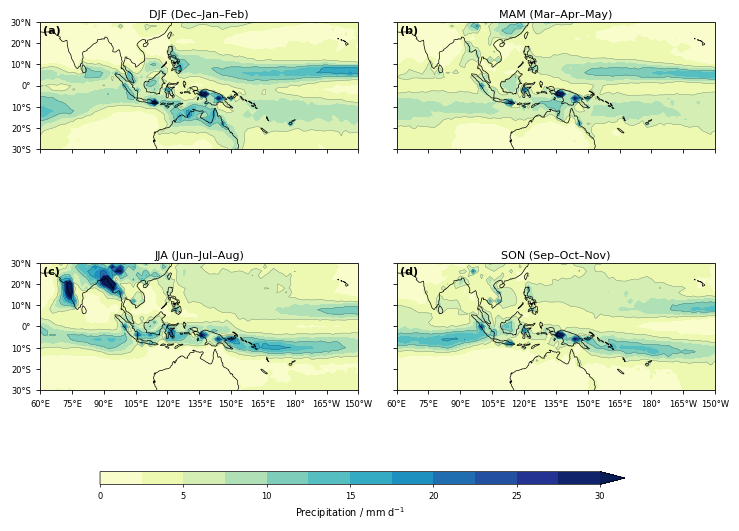

In [53]:
plot_seasonal_pr(
    data_dict, lats, lons,
    extent      = [60, 200, -30, 30],
    extend      ="max",
    central_lon = 125,
    dlon=15, dlat=10,
    # title  = "Seasonal Mean Precipitation – Maritime Continent",
    # output = "/work/mh1498/m301257/code_extreme_event/figures/seasonal_pr_MC.png",
)

(<Figure size 750x580 with 5 Axes>,
 array([[<GeoAxes: title={'center': 'DJF (Dec–Jan–Feb)'}>,
         <GeoAxes: title={'center': 'MAM (Mar–Apr–May)'}>],
        [<GeoAxes: title={'center': 'JJA (Jun–Jul–Aug)'}>,
         <GeoAxes: title={'center': 'SON (Sep–Oct–Nov)'}>]], dtype=object))

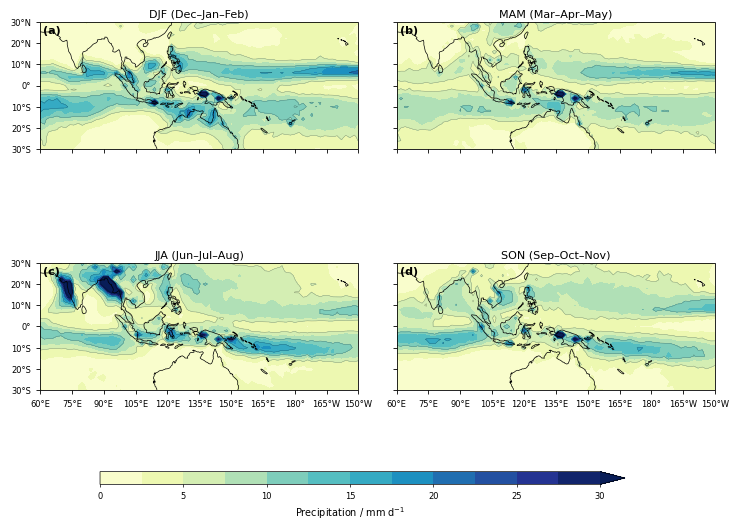

In [54]:
plot_seasonal_pr(
    data_dict_p4k, lats, lons,
    extent      = [60, 200, -30, 30],
    extend      ="max",
    central_lon = 125,
    dlon=15, dlat=10,
    # title  = "Seasonal Mean Precipitation – Maritime Continent",
    # output = "/work/mh1498/m301257/code_extreme_event/figures/seasonal_pr_MC.png",
)

(<Figure size 750x580 with 5 Axes>,
 array([[<GeoAxes: title={'center': 'DJF (Dec–Jan–Feb)'}>,
         <GeoAxes: title={'center': 'MAM (Mar–Apr–May)'}>],
        [<GeoAxes: title={'center': 'JJA (Jun–Jul–Aug)'}>,
         <GeoAxes: title={'center': 'SON (Sep–Oct–Nov)'}>]], dtype=object))

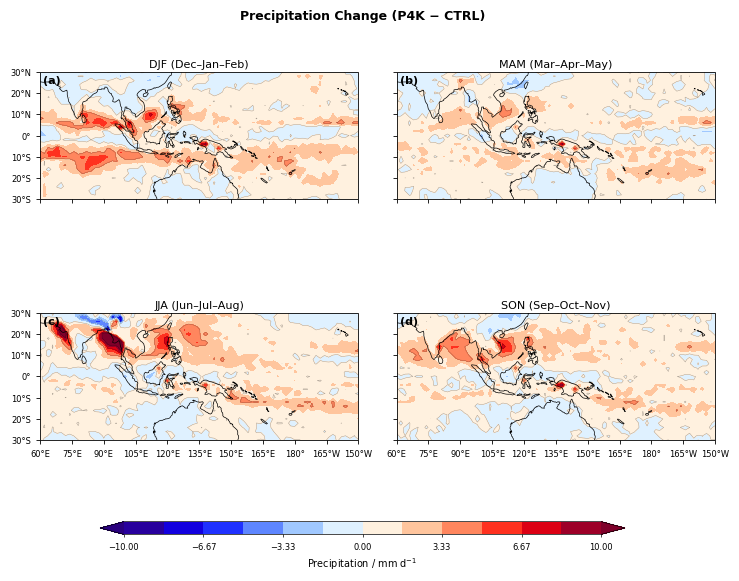

In [55]:
seasons = ["DJF", "MAM", "JJA", "SON"]
data_dict_diff = {s: data_dict_p4k[s] - data_dict[s] for s in seasons}

plot_seasonal_pr(
    data_dict_diff, lats, lons,
    extent=[60, 200, -30, 30],
    extend="both",
    central_lon=125,
    dlon=15, dlat=10,
    cmap=cmaps.NCV_blu_red,
    vmin=-10, vmax=10,
    title="Precipitation Change (P4K − CTRL)",
)